In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from causalinference import CausalModel
from scipy import stats as st
from scipy.stats import norm, ttest_ind
from tqdm.auto import tqdm

## Формирование датасета для домашки, закладывание эффектов

### Описание
Вы продуктовый аналитик в классифайде недвижимости. Команда сделала дополнительную рассылку на объявления, которая вела на онбординг покупки платных услуг.  Основная цель - команда хотела увеличить выручку с объявлений. Рассылка была произведена без рандомного деления на тест и контроль. Поэтому мы не сможем использовать классический АБ-тест.
Основная метрика теста - выручка (revenue) на объявление. Вам предстоит проанализировать с помощью PSM выручку на объявления, как она поменялась для тех, кто реагировал на рассылку (treatment).

### Данные

Данные csv dataset_for_psm_hw.csv
схема датасета:
- price - цена квартиры
- year - год постройки квартиры
- floor - этаж
- rooms - кол-во комнат в квартире
- square - площадь квартиры
- revenue - выручка
- treatment - отреалировал на рассылку
- id - id-объявления


### Задания

**1) Выгрузите данные по объявлениям, параметрам а так же выручкой и параметром treatment.**

**2) Проведите EDA**
- 2.1 Укажите абсолютную разницу между средними по параметру 'square'
- 2.2. Укажите стандартизированную разницу Cohen D effect size, где стандартное отклонения - это std по всему датафрейму по этой метрике
- 2.3. Какая доля объявлений получила treatment?
- 2.4. Найдите стандартизированный effect size Cohen D для метрики revenue (разница для объявлений которые воспользовались treatment и нет)
- 2.5. Можно ли сказать, что группы treatment == True и treatment == False одинаково распределены по параметрам? И репрезентативны друг другу по этим параметрам?
- 2.6. Можем ли мы напрямую сравнивать целевую метрику между treatment и control для нахождения эффекта?

**3) Оцените эффект с помощью PSM**
- 3.1. Какой "сырой" эффект (разницу между treatment и control) по данным видит модель?
- 3.2. Есть ли стат. значимый эффект при варианте замера ATE?
- 3.3. укажите p-value при оценке эффекта ATE?
- 3.4. Какой размер эффекта ATE нашла PSM методика?
- 3.5. Есть ли стат. значимый эффект при варианте замера ATE?
- 3.6. укажите p-value при оценке эффекта ATE?
- 3.7. Какой размер эффекта ATE нашла PSM методика?
- 3.8. Как считаете, что значит наличие стат значимости в ATC и ATE и отсутствие значимости в ATT?

## 1) Выгрузка

In [140]:
data = pd.read_csv('dataset_for_psm_hw.csv', index_col = 0)
treatment = 'treatment'
outcome = 'revenue'
data.treatment = data.treatment.astype(bool)
df = data.copy()

df

,price,year,floor,rooms,square,revenue,treatment,id
0,16500000.00,2009,17.00,1,39,0.00,False,0
1,23000000.00,2021,5.00,1,45,0.00,False,1
2,44700000.00,2015,4.00,2,79,0.00,True,2
3,10500000.00,2011,23.00,1,30,0.00,True,3
4,40000000.00,2022,5.00,2,71,0.00,False,4
...,...,...,...,...,...,...,...,...
20368,19000000.00,2022,4.00,1,41,0.00,True,20368
20369,17500000.00,1969,2.00,2,40,0.00,False,20369
20370,21000000.00,2023,5.00,1,38,0.00,True,20370
20371,82500000.00,2022,12.00,3,91,0.00,False,20371


## 2) EDA

In [141]:
# найдите пааметры по которым различаются treatment == True и treatment == False
df.groupby('treatment').mean()

,price,year,floor,rooms,square,revenue,id
treatment,,,,,,,
False,32870957.74,2013.51,6.17,1.97,62.83,105.14,10208.12
True,38407008.06,2013.83,6.23,2.20,70.91,162.64,10151.70


In [142]:
# какая абсолютная разница в средних значениях между теми объявлениями, которые воспользовались treatment и нет, по параметру square.
# 2.1 Укажите абсолютную разницу между средними по параметру 'square'
# 2.2. Укажите стандартизированную разницу Cohen D effect size, где стандартное отклонения - это std по всему датафрейму по этой метрике

abs_diff = abs(df.groupby('treatment').mean()['square'][0] - df.groupby('treatment').mean()['square'][1])
std_diff = abs_diff / df['square'].std()
print('2.1. Абсолютная разница =', abs_diff)
print('2.2. Стандартизированная разница Cohen D effect size=', std_diff)

2.1. Абсолютная разница = 8.082047676335662
2.2. Стандартизированная разница Cohen D effect size= 0.19958690245886035


In [143]:
# 2.3. какая доля объявлений получила treatment?
print('Treatment воспользовались {} объявлений'.format(round(df['treatment'].mean(), 3)))

Treatment воспользовались 0.392 объявлений


In [144]:
# 2.4. Найдите стандартизированный effect size Cohen D для метрики revenue (разница для объявлений которые воспользовались treatment и нет)
abs_diff = abs(df.groupby('treatment').mean()['revenue'][0] - df.groupby('treatment').mean()['revenue'][1])
std_diff = abs_diff / df['revenue'].std()
print('2.4. Стандартизированная разница Cohen D effect size=', std_diff)

2.4. Стандартизированная разница Cohen D effect size= 0.06544894156840654


## Построим графики распределения по параметрам в зависимости от treatment

<Axes: xlabel='square', ylabel='Density'>

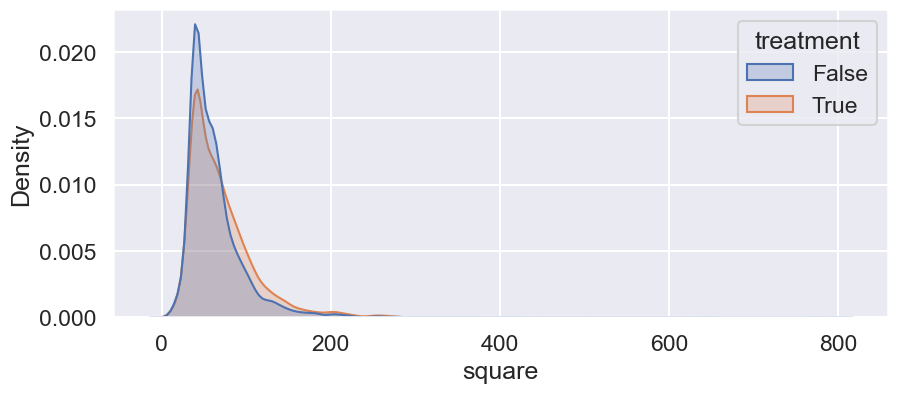

In [145]:
plt.figure(figsize = (10, 4))
sns.kdeplot(data = df, x = 'square', hue = 'treatment', fill = True, common_norm = False)

<Axes: xlabel='price', ylabel='Density'>

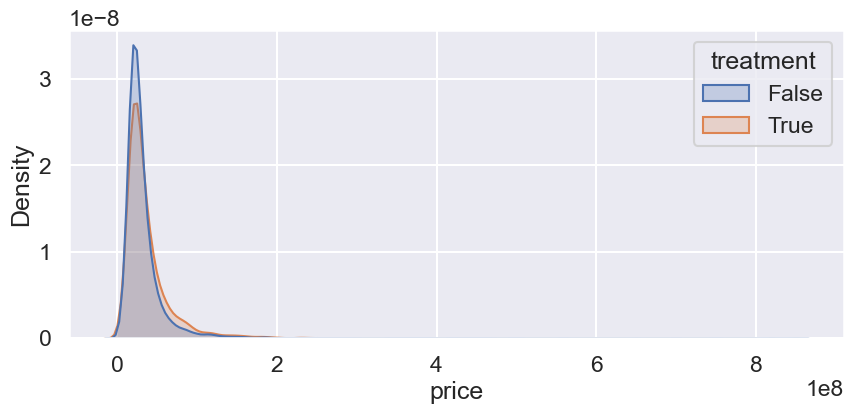

In [146]:
plt.figure(figsize = (10, 4))
sns.kdeplot(data = df, x = 'price', hue = 'treatment', fill = True, common_norm = False)

<Axes: xlabel='floor', ylabel='Density'>

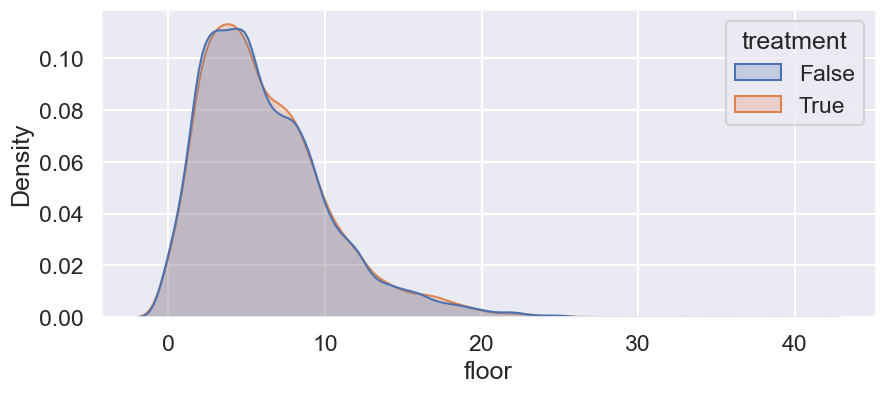

In [147]:
plt.figure(figsize = (10, 4))
sns.kdeplot(data = df, x = 'floor', hue = 'treatment', fill = True, common_norm = False)

<Axes: xlabel='year', ylabel='Density'>

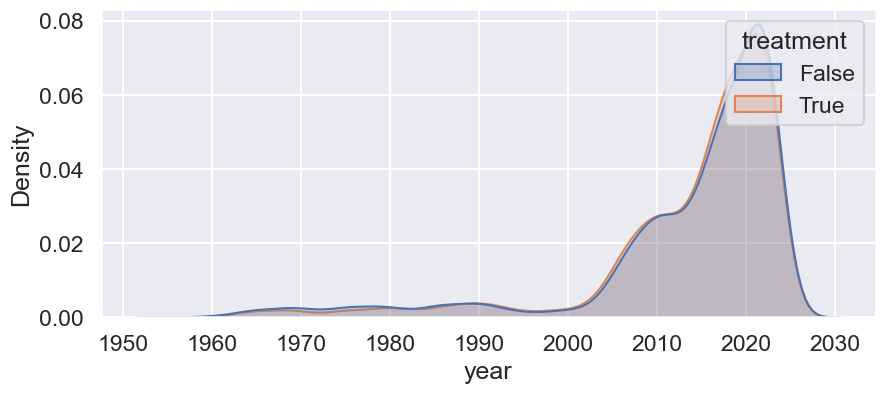

In [148]:
plt.figure(figsize = (10, 4))
sns.kdeplot(data = df, x = 'year', hue = 'treatment', fill = True, common_norm = False)

<Axes: xlabel='rooms', ylabel='Density'>

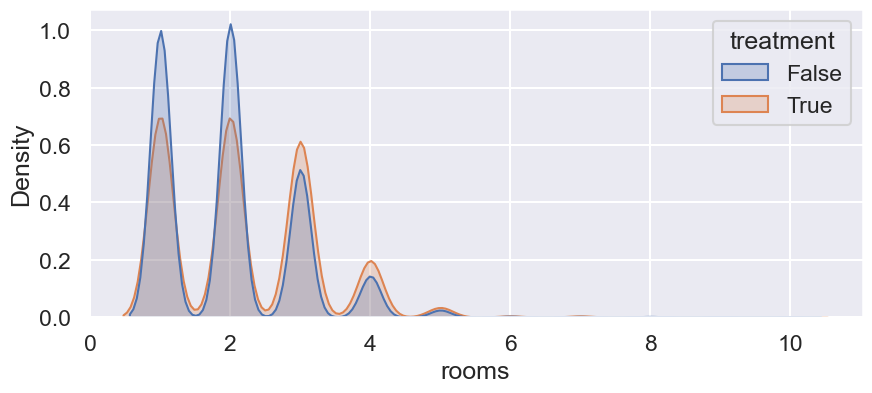

In [149]:
plt.figure(figsize = (10, 4))
sns.kdeplot(data = df, x = 'rooms', hue = 'treatment', fill = True, common_norm = False)

**2.5. Можно ли сказать, что группы treatment == True и treatment == False одинаково распределены по параметрам? И репрезентативны друг другу по этим параметрам?**
- Нет (**правильный ответ.** Группы различаются достаточно сильно сразу по нескольким параметрам)
- Да (кажется они все таки различаются. Давай посмотрим пристальнее)

**2.6. Можем ли мы напрямую сравнивать целевую метрику между treatment и control для нахождения эффекта?**
- Да. Что меня остановит (хороший настрой, но ответ не правильный)
- Нет ведь по наблюдаемым параметрам есть различия в группах. (Верно. Действительно мы не можем использовать для сравнение treatment и control так он есть, т.к. по наблюдаемым параметрам у нас есть расхождения, группы различаются и в этом может быть искажение эффекта)

## 3) Оценка эффекта
Оценим ATE эффект через PSM

In [150]:
%%time
y = df[outcome].values
t = df[treatment].values
X_ = df[['year', 'floor', 'rooms', 'price', 'square']]
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_),
                 columns=X_.columns).values
model = CausalModel(y, t, X_scaled)
print(model.summary_stats)
model.est_propensity() # сделаем оценку propensity score с помощью логистической регресии
print(model.propensity) # результаты отработки модели

propensity_score = model.raw_data['pscore']
propensity_score = np.where(propensity_score==1, 0.9999999999, propensity_score)

a = propensity_score
b = 1 - propensity_score
c = a / b
propensity_logit = pd.DataFrame(np.log(c)).replace(np.inf, 0).values # преобразование в propensity_logit

model = CausalModel(y, t, propensity_logit) # инициируем модель причинной связи
model.est_via_matching()
print(model.estimates)


Summary Statistics

                     Controls (N_c=12386)        Treated (N_t=7987)             
       Variable         Mean         S.d.         Mean         S.d.     Raw-diff
--------------------------------------------------------------------------------
              Y      105.143      700.598      162.644     1098.105       57.502

                     Controls (N_c=12386)        Treated (N_t=7987)             
       Variable         Mean         S.d.         Mean         S.d.     Nor-diff
--------------------------------------------------------------------------------
             X0       -0.011        1.030        0.016        0.952        0.027
             X1       -0.006        1.000        0.009        1.000        0.015
             X2       -0.090        0.954        0.140        1.053        0.229
             X3       -0.058        0.941        0.091        1.079        0.147
             X4       -0.078        0.948        0.121        1.065        0.198


Esti

In [151]:
# 3.1. Какой "сырой" эффект (разницу между treatment и control) по данным видит модель?
print('3.1. Наблюдаемый, "сырой" эффект составил =', round(model.summary_stats['rdiff'], 3))

3.1. Наблюдаемый, "сырой" эффект составил = 57.502


In [152]:
# 3.2. Есть ли стат. значимый эффект при варианте замера ATE?
# 3.3. укажите p-value при оценке эффекта ATE?
# 3.4. Какой размер эффекта ATE нашла PSM методика?

metric = 'ate'
model_estimates = model.estimates.get('matching')
z = model_estimates.get(metric) / model_estimates.get(metric+'_se')
p_value_z = (1 - st.norm.cdf(abs(z))) * 2

if p_value_z < 0.05:
    print('3.2. Результаты стат. значимы')
else:
    print('3.2. Результаты не стат. значимы')

print('3.3. p-value =', p_value_z)
print('3.4. Размер эффекта ATE =', round(model_estimates['ate'], 3))

3.2. Результаты стат. значимы
3.3. p-value = 0.00668576091715023
3.4. Размер эффекта ATE = 64.702


In [153]:
# 3.5. Есть ли стат. значимый эффект при варианте замера ATT?
# 3.6. укажите p-value при оценке эффекта ATT?
# 3.7. Какой размер эффекта ATE нашла PSM методика?

metric = 'att'
model_estimates = model.estimates.get('matching')
z = model_estimates.get(metric) / model_estimates.get(metric+'_se')
p_value_z = (1 - st.norm.cdf(abs(z))) * 2

if p_value_z < 0.05:
    print('3.5. Результаты стат. значимы')
else:
    print('3.5. Результаты не стат. значимы')

print('3.6. p-value =', p_value_z)
print('3.7. Размер эффекта ATT =', round(model_estimates['att'], 3))

3.5. Результаты не стат. значимы
3.6. p-value = 0.13907300322682037
3.7. Размер эффекта ATT = 41.654


**3.8. Как считаете, что значит наличие стат значимости в ATC и ATE и отсутствие значимости в ATT?**
- При "сведении" матсинга к treatment == True размер выборки меньше, чем при обратной стратегии матчинга и мера разброса целевой метрикики revenue выше. Что снижает мощность теста именно при этом направлении матчинга. (Да это верный ответ. После того как вы сматчили группы работают те же принципы, что и для классических АБ. Чем больше выборка - тем выше мощность, чем вариативнее метрика тем ниже мощность)
- PSM всегда снижает стат.значимость в направлении ATT (Не верно. PSM не так избирателен)
- В treatment группу всегда попадают более активные наблюдения, и у них по умолчанию revenue должно быть выше. Поэтому для treatment группы эффект всегда более маленький и методика такой меньший uplift находит менее уверено. (Не верно. Такой дисбаланс не связан с активностью групп)
- Метрика revenue распределена не нормально. Из-за чего в ATT способе замера эффекта мощность снижается. (Не верно. Действительно для маленьких выборок это могло бы влиять на результаты оценки эффекта. но для десятков тысяч наблюдений сам характер распределения часто не оказывает слияния на сравнения средних и в АБ-тесте и в PSM)